In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

### Implementation of Standardized Intensity and Recover Time Analysis

In [2]:
# Read the data files
template = pd.read_csv('template.csv')
panel = pd.read_csv('../by_coin_panels/BTC_panels/panel_BTC_avg_e_spread.csv')

# Prepare results DataFrame by copying the template
results = template.copy()

# Extract time column and event columns
time_col = panel.columns[0]
event_cols = panel.columns[1:]

# Process each event
for i, event_col in enumerate(event_cols):
    
    # Find corresponding row in template/results
    matching_rows = results.iloc[:, 0] == event_col
    if not any(matching_rows):
        print(f"Warning: No matching row in template for {event_col}")
        continue
    row_idx = matching_rows.idxmax()
    
    # Extract time series for this event
    event_data = panel[[time_col, event_col]].copy()
    event_data.columns = ['time', 'value']
    event_data = event_data.dropna()  # Remove any NaN values
    
    # 1. Calculate pre_mean and pre_std (-600 to -1 minutes)
    pre_period = event_data[(event_data['time'] >= -600) & (event_data['time'] <= -1)]
    pre_mean = pre_period['value'].mean()
    pre_std = pre_period['value'].std()
    
    # 2. Calculate 20-minute moving average (MA20) starting from minute 0
    post_period = event_data[event_data['time'] >= 0].copy()
    post_period['MA20'] = post_period['value'].rolling(window=20, min_periods=1).mean()
    
    # Store MA20 data for first 300 minutes (for potential visualization)
    ma20_600 = post_period[post_period['time'] <= 600][['time', 'MA20']].copy()
    
    # 3. Find peak_es (max of MA20) and corresponding peak_minute
    post_600 = post_period[post_period['time'] <= 600].copy()
    if post_600.empty or post_600['MA20'].isna().all():
        print(f"Warning: No valid MA20 data for {event_col}")
        continue
    
    peak_es = post_600['MA20'].max()
    peak_indices = post_600[post_600['MA20'] == peak_es].index
    if len(peak_indices) == 0:
        print(f"Warning: Couldn't find peak for {event_col}")
        continue
    peak_idx = peak_indices[0]  # Take the first occurrence if multiple
    peak_minute = post_600.loc[peak_idx, 'time']
    
    # 3.5 Alarm System: Check if MA20 reaches 85% of peak after the peak (valid_pes)
    post_peak = post_600[(post_600['time'] > peak_minute + 20) & (post_600['time'] <= 600)]
    valid_pes = bool(all(post_peak['MA20'] < 0.85 * peak_es)) # For those having false, I chekced the visualizations
    
    # 4. Calculate standardized_intensity
    standardized_intensity = (peak_es - pre_mean) / pre_std if pre_std > 0 else np.nan
    
    
    ##### Recovery calculations #####
    recovery_threshold = 1.5 * pre_mean
    recover_minute = np.nan
    recover_time = np.nan
    
    # Find first 20 consecutive minutes below recovery threshold
    valid_times = post_period[(post_period['time'] > peak_minute) & (post_period['time'] <= 600)]
    for start_idx in range(len(valid_times) - 19): # 20 consecutive minutes
        window = valid_times.iloc[start_idx:start_idx + 20]
        
        # Ensure window has exactly 20 minutes with consecutive times
        if len(window) != 20:
            continue
            
        # Check if all values in this window are below recovery threshold
        if all(window['MA20'] < recovery_threshold):
            recover_minute = window['time'].iloc[0]  # First minute of recovery
            recover_time = recover_minute - peak_minute
            break
        
    # If recover_minute is still NaN, set it to 600
    if np.isnan(recover_minute):
        recover_minute = 600
        recover_time = recover_minute - peak_minute
    
    # Update results for this event
    results.loc[row_idx, 'pre_mean'] = pre_mean
    results.loc[row_idx, 'pre_std'] = pre_std
    results.loc[row_idx, 'peak_es'] = peak_es
    results.loc[row_idx, 'valid_pes'] = valid_pes
    results.loc[row_idx, 'peak_minute'] = peak_minute
    results.loc[row_idx, 'standardized_intensity'] = standardized_intensity
    results.loc[row_idx, 'recover_minute'] = recover_minute
    results.loc[row_idx, 'recover_time'] = recover_time

# Save results to CSV
results.to_csv('peak_recover_analysis.csv', index=False)
print("Analysis complete. Results saved to 'peak_recover_analysis.csv'")

/var/folders/6x/n8nj7kfs5nq5msthcdc6t3c00000gn/T/ipykernel_2022/3253401815.py:90: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'True' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  results.loc[row_idx, 'valid_pes'] = valid_pes


Analysis complete. Results saved to 'peak_recover_analysis.csv'


### An Overview of the Analysis Outputs

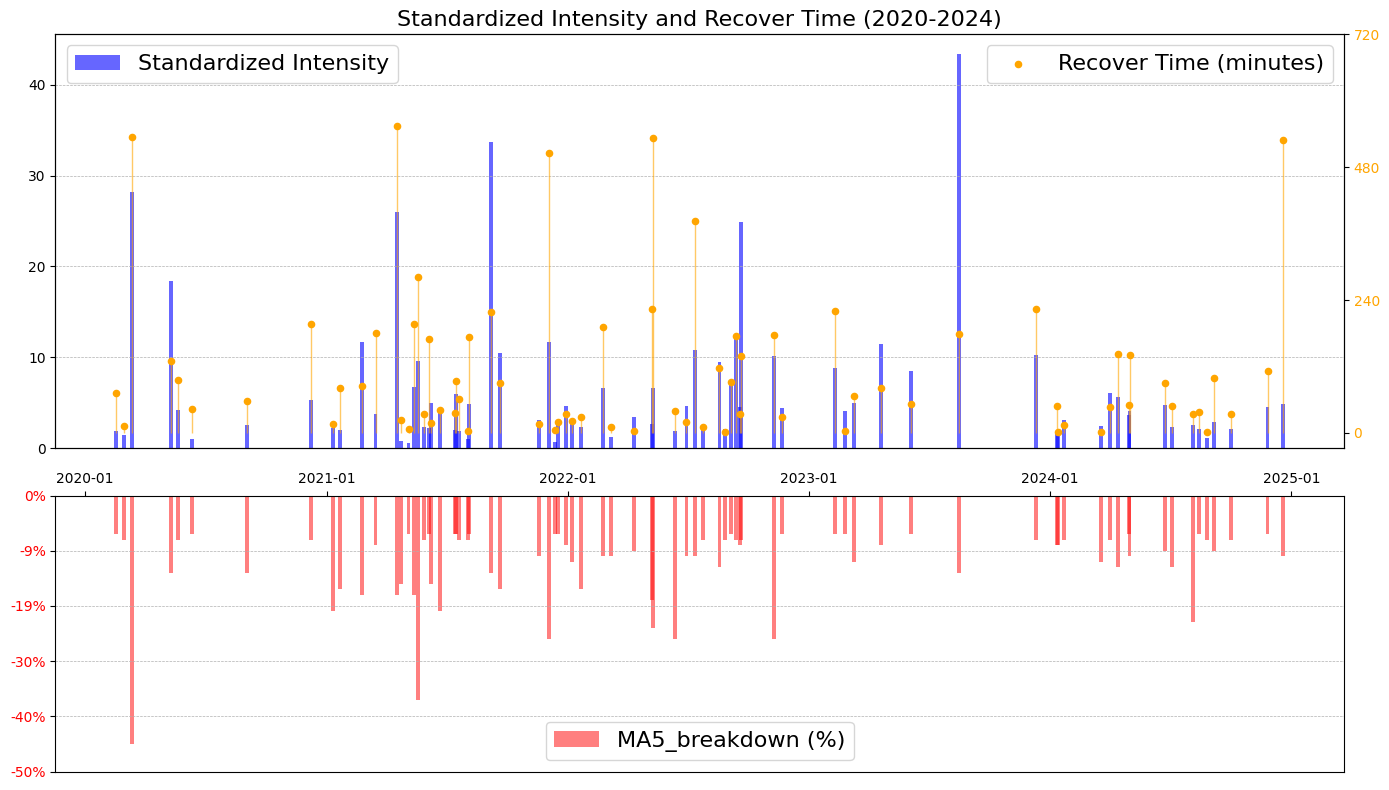

In [3]:
# Load the datasets
peak_recover = pd.read_csv("peak_recover_analysis.csv")
event_filter = pd.read_csv("event_filter(incl_ob_hour_&_types).csv")

# Merge the two datasets on event index (assuming event names align)
data = pd.concat([peak_recover, event_filter], axis=1)
# convert MA5 to percentage
data['MA5'] = data['MA5'].str.rstrip('%').astype(float) / 100.0

# Convert date column to datetime format
data['date'] = pd.to_datetime(data['date'], format='%Y/%m/%d')

# Sort data by date
data = data.sort_values('date')

# Set up the figure and axes
fig, (ax1, ax3) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios': [3, 2]})

# Main plot: Standardized Intensity and Recover Time
# Plot standardized_intensity on the primary y-axis
ax1.bar(data['date'], data['standardized_intensity'], color='blue', alpha=0.6, width=6, label='Standardized Intensity')
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)

# Create a secondary y-axis for recover_time
ax2 = ax1.twinx()
ax2.scatter(data['date'], data['recover_time'], color='orange', alpha=1, label='Recover Time', s=20)
ax2.vlines(data['date'], ymin=0, ymax=data['recover_time'], color='orange', alpha=0.6, linewidth=1)
ax2.tick_params(axis='y', labelcolor='orange')
max_recover_time = data['recover_time'].max()
ax2.set_yticks(np.arange(0, max_recover_time + 240, 240))  # Set y-ticks to be multiples of 240

# Format x-axis as time
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax1.set_xticks([])  # Hide x-ticks for the main plot
ax1.set_title('Standardized Intensity and Recover Time (2020-2024)', fontsize = 16)

# Subplot for MA5

ax3.bar(data['date'], data['MA5'], color='red', alpha = 0.5,width = 6, label='MA5_breakdown')
ax3.set_ylim(-0.5, 0)  # Set y-axis limits from -50% to 0%

def to_percent(y, position):
    return f"{int(y * 100)}%"
ax3.yaxis.set_major_formatter(FuncFormatter(to_percent)) # format the y-axis to percentage
ax3.xaxis.set_ticks_position('top')  # Set the ticks position to top
ax3.tick_params(axis='y', labelcolor='red')
ax3.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5)

# Format x-axis for the subplot
ax3.xaxis.set_major_locator(mdates.YearLocator())
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)

# Add legends to both plots
ax1.legend(loc='upper left', fontsize = 16)
ax2.legend(labels=['Recover Time (minutes)'],loc='upper right', fontsize = 16)
ax3.legend(labels=['MA5_breakdown (%)'],loc='lower center', fontsize = 16)

# Adjust layout
fig.tight_layout()
plt.show()


### Overall Distribution Characteristics


==== Descriptive statistics - overall distribution characteristics ====
       standardized_intensity  recover_time  peak_minute
count                   76.00         76.00        76.00
mean                     6.45        112.99       109.47
std                      7.65        136.09       143.15
min                      0.63          1.00         0.00
25%                      2.22         22.75        35.75
50%                      4.08         59.50        52.50
75%                      6.81        170.00        78.00
max                     43.37        554.00       558.00

Skewness and Kurtosis:
                        Skewness  Kurtosis
standardized_intensity     2.809     8.544
recover_time               1.979     3.477
peak_minute                1.863     2.164


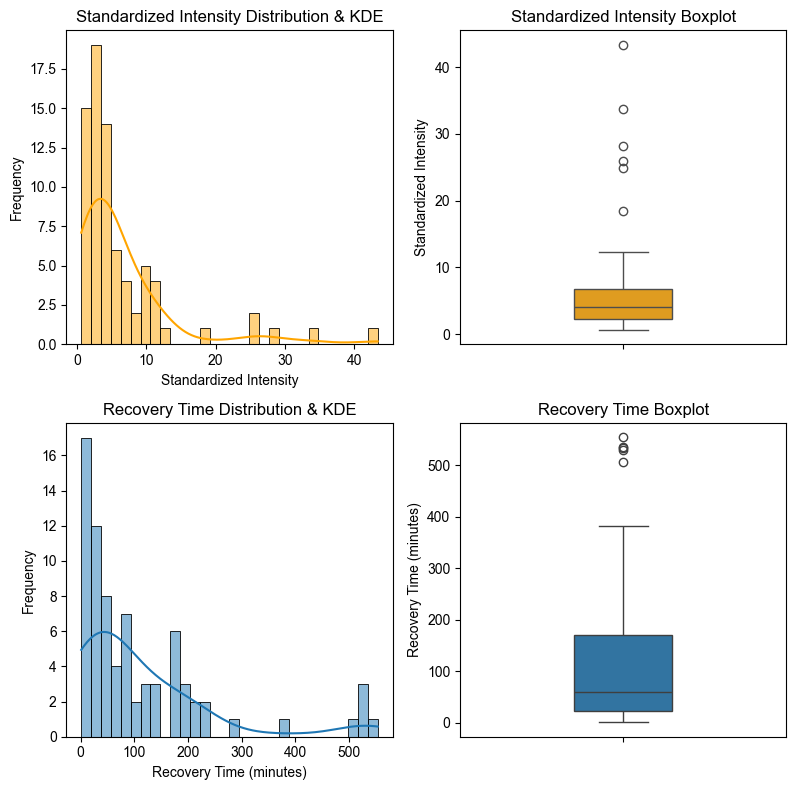

In [4]:
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial']  # or ['DejaVu Sans']
plt.rcParams['font.family'] = 'sans-serif'

# 1. Descriptive statistics - overall distribution characteristics
print("\n==== Descriptive statistics - overall distribution characteristics ====")
stats_cols = ['standardized_intensity', 'recover_time', 'peak_minute']
desc_stats = results[stats_cols].describe()
desc_stats = desc_stats.round(2)
print(desc_stats) 

# Calculate skewness and kurtosis
skew_kurt = pd.DataFrame({
    'Skewness': [stats.skew(results[col].dropna()) for col in stats_cols],
    'Kurtosis': [stats.kurtosis(results[col].dropna()) for col in stats_cols]
}, index=stats_cols)
skew_kurt = skew_kurt.round(3)
print("\nSkewness and Kurtosis:")
print(skew_kurt)

# 2. Visualize distribution
plt.figure(figsize=(12, 8))

# distribution of standardized intensity
plt.subplot(2, 3, 1)
sns.histplot(results['standardized_intensity'], kde=True, bins = 30, color = 'orange')
plt.title('Standardized Intensity Distribution & KDE')
plt.xlabel('Standardized Intensity')
plt.ylabel('Frequency')

plt.subplot(2, 3, 2)
sns.boxplot(y=results['standardized_intensity'], width=0.3, color = 'orange')
plt.title('Standardized Intensity Boxplot')
plt.ylabel('Standardized Intensity')

# distribution of recover time
plt.subplot(2, 3, 4)
sns.histplot(results['recover_time'], kde=True, bins = 30)
plt.title('Recovery Time Distribution & KDE')
plt.xlabel('Recovery Time (minutes)')
plt.ylabel('Frequency')

plt.subplot(2, 3, 5)
sns.boxplot(y=results['recover_time'], width=0.3)
plt.title('Recovery Time Boxplot')
plt.ylabel('Recovery Time (minutes)')

plt.tight_layout()
plt.show()

### Statistical Significance Test on Standardized Intensity & Recover Time

In [5]:
# 1. Distribution Characteristics Tests
'''
Shapiro-Wilk test is skipped because apparently the data is not normally distributed.

# Shapiro-Wilk test
shapiro_stat, shapiro_p = stats.shapiro(results['standardized_intensity'])
print(f"Shapiro-Wilk test: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.4e}")
if shapiro_p < 0.05:
    print("The data significantly deviates from a normal distribution.")
else:
    print("The data does not significantly deviate from a normal distribution.")

# 2. Single Sample t-test
t_stat, t_p = stats.ttest_1samp(results['standardized_intensity'], popmean=0)  # Assuming the mean is 0
print(f"One-sample t-test: t-statistic={t_stat:.4f}, p-value={t_p:.4e}")
if t_p < 0.05:
    print("The mean of standardized_intensity is significantly different from 0.")
else:
    print("The mean of standardized_intensity is not significantly different from 0.")

# 3. Single Sample Non-parametric Test (e.g., Single Sample Kolmogorov-Smirnov Test)
# Test whether it is significantly different from a normal distribution with mean 0
ks_stat, ks_p = stats.kstest(results['standardized_intensity'], 'norm', args=(0, np.std(results['standardized_intensity'])))
print(f"Kolmogorov-Smirnov test: statistic={ks_stat:.4f}, p-value={ks_p:.4e}")
if ks_p < 0.05:
    print("The data significantly deviates from a normal distribution with mean=0.")
else:
    print("The data does not significantly deviate from a normal distribution with mean=0.")
'''

# 4. 效应量计算
cohens_d = np.mean(results['standardized_intensity']) / np.std(results['standardized_intensity'])
print(f'\nCohen\'s d Effect Size: {cohens_d:.3f}')

# 5. Extreme Value Analysis (Quantiles)
# Calculate the 5th and 95th percentiles
q5, q95 = np.percentile(results['standardized_intensity'], [5, 95])
print(f"5th percentile: {q5:.4f}, 95th percentile: {q95:.4f}")

# 标记极端值
extreme_values = results[(results['standardized_intensity'] < q5) | (results['standardized_intensity'] > q95)]
print(f"Number of extreme values (outside 5th-95th percentiles): {len(extreme_values)}")


Cohen's d Effect Size: 0.849
5th percentile: 1.0207, 95th percentile: 25.1630
Number of extreme values (outside 5th-95th percentiles): 8


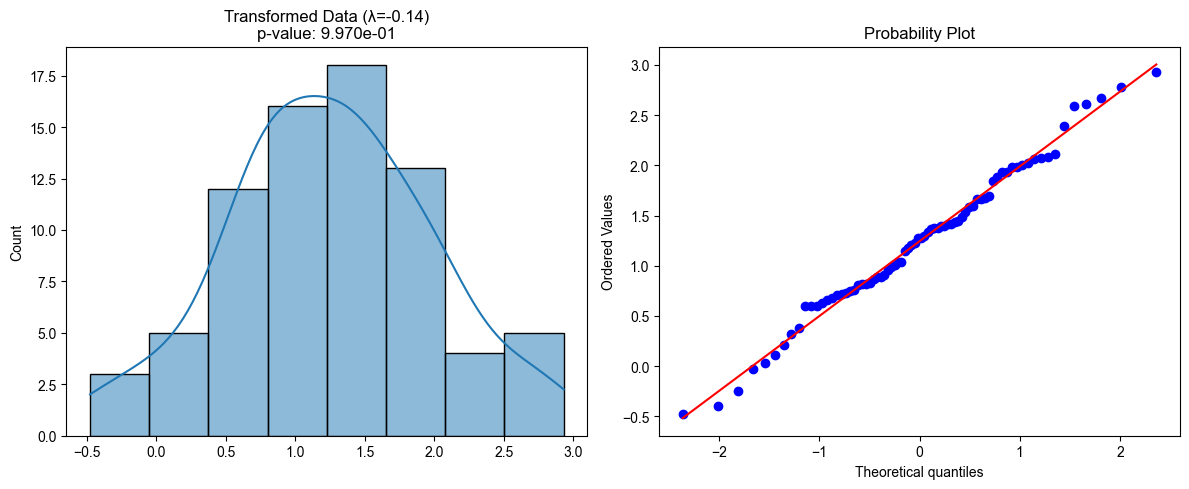

In [6]:
from scipy import stats
from scipy.stats import boxcox, normaltest
from statsmodels.robust import mad
from sklearn.utils import resample

# Box-Cox Transformation
adjusted_data = results['standardized_intensity'] + 1e-9
transformed, lambda_ = boxcox(adjusted_data)
results['transformed'] = transformed

# 3. Normalization Verification
# D'Agostino's Test
k2_stat, pval_norm = normaltest(transformed)

# Visualization Comparison
plt.figure(figsize=(12,5))
plt.subplot(121)
sns.histplot(transformed, kde=True)
plt.title(f'Transformed Data (λ={lambda_:.2f})\np-value: {pval_norm:.3e}')

plt.subplot(122)
stats.probplot(transformed, dist="norm", plot=plt)
plt.tight_layout()
plt.show()

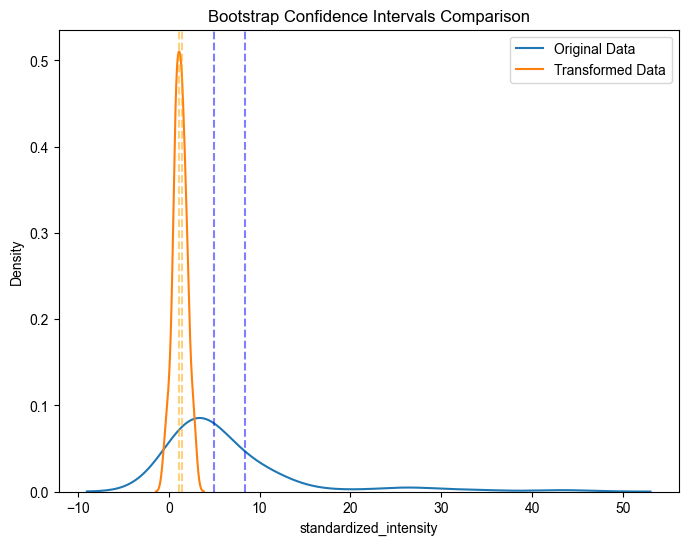

In [7]:
# Bootstrap Confidence Intervals
def bootstrap_ci(data, n_bootstraps=1000):
    means = [np.mean(resample(data)) for _ in range(n_bootstraps)]
    return np.percentile(means, [2.5, 97.5])

# Calculate two confidence intervals
original_ci = bootstrap_ci(results['standardized_intensity'])
transformed_ci = bootstrap_ci(transformed)

# Visualization Comparison
plt.figure(figsize=(8,6))
sns.kdeplot(results['standardized_intensity'], label='Original Data')
sns.kdeplot(transformed, label='Transformed Data')
plt.axvline(original_ci[0], color='blue', linestyle='--', alpha=0.5)
plt.axvline(original_ci[1], color='blue', linestyle='--', alpha=0.5)
plt.axvline(transformed_ci[0], color='orange', linestyle='--', alpha=0.5)
plt.axvline(transformed_ci[1], color='orange', linestyle='--', alpha=0.5)
plt.legend()
plt.title('Bootstrap Confidence Intervals Comparison')
plt.show()

In [8]:
median_val = np.median(results['standardized_intensity'])
mad_val = mad(results['standardized_intensity'])

# Calculate Robust Z-values
robust_z = 0.6745 * (results['standardized_intensity'] - median_val) / mad_val
outliers = results[np.abs(robust_z) > 3.5]

print(f'''
[Robust Statistical Report]
Median: {median_val:.2f}
MAD: {mad_val:.2f}
Number of Outliers (Robust Z-score > 3.5): {len(outliers)}/{len(results)} ({len(outliers)/len(results):.1%})
''')


[Robust Statistical Report]
Median: 4.08
MAD: 2.95
Number of Outliers (Robust Z-score > 3.5): 5/76 (6.6%)



In [9]:
print(f'''
[Final Analysis Report]
1. Data Conversion Effectiveness:
   • Original Data Skewness: {stats.skew(results['standardized_intensity']):.2f}
   • Transformed Data Skewness: {stats.skew(transformed):.2f}
   • Normal Distribution Test p-value: {pval_norm:.3e} {'(Passed)' if pval_norm>0.05 else '(Failed)'}

2. Robust Metrics:
   • Median: {median_val:.2f}
   • MAD: {mad_val:.2f}
   • Outlier Ratio: {len(outliers)/len(results):.1%}

3. Confidence Interval Comparison:
   • Original Data Mean CI: [{original_ci[0]:.2f}, {original_ci[1]:.2f}]
   • Transformed Data Mean CI: [{transformed_ci[0]:.2f}, {transformed_ci[1]:.2f}]

Suggested Next Steps:
{'- Use parametric tests' if pval_norm>0.05 else '- Use non-parametric methods'}
{'' if len(outliers)/len(results)<0.1 else '- Execute outlier handling'}
''')


[Final Analysis Report]
1. Data Conversion Effectiveness:
   • Original Data Skewness: 2.81
   • Transformed Data Skewness: 0.01
   • Normal Distribution Test p-value: 9.970e-01 (Passed)

2. Robust Metrics:
   • Median: 4.08
   • MAD: 2.95
   • Outlier Ratio: 6.6%

3. Confidence Interval Comparison:
   • Original Data Mean CI: [4.96, 8.39]
   • Transformed Data Mean CI: [1.08, 1.41]

Suggested Next Steps:
- Use parametric tests




Pearson correlation: 0.5137, p-value: 2.0792e-06
Spearman correlation: 0.6970, p-value: 2.6879e-12
                            OLS Regression Results                            
Dep. Variable:           recover_time   R-squared:                       0.264
Model:                            OLS   Adj. R-squared:                  0.254
Method:                 Least Squares   F-statistic:                     26.52
Date:                Fri, 07 Mar 2025   Prob (F-statistic):           2.08e-06
Time:                        11:52:30   Log-Likelihood:                -469.10
No. Observations:                  76   AIC:                             942.2
Df Residuals:                      74   BIC:                             946.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
--------------------

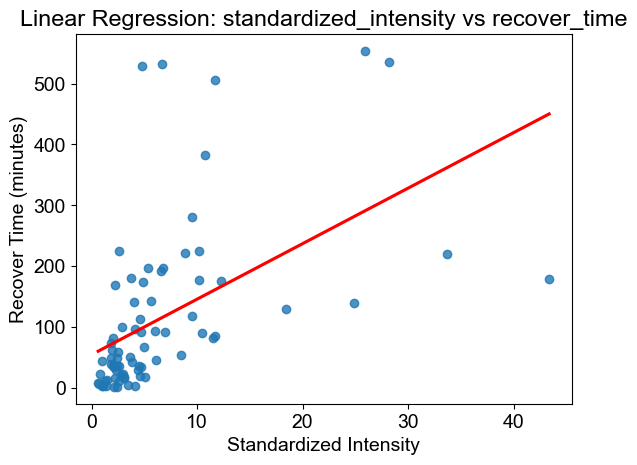

In [25]:
# 1. Correlation Analysis (between standardized_intensity and recover_minute)
# Calculate the Pearson correlation coefficient
pearson_corr, pearson_p = stats.pearsonr(results['standardized_intensity'], results['recover_time'])
print(f"Pearson correlation: {pearson_corr:.4f}, p-value: {pearson_p:.4e}")

# Calculate the Spearman correlation coefficient
spearman_corr, spearman_p = stats.spearmanr(results['standardized_intensity'], results['recover_time'])
print(f"Spearman correlation: {spearman_corr:.4f}, p-value: {spearman_p:.4e}")

# 2. Regression Analysis
# Add a constant term
X = sm.add_constant(results['standardized_intensity'])
y = results['recover_time']

# Build a linear regression model
model = sm.OLS(y, X).fit()

# Output the regression results
print(model.summary())

# Visualize the regression results
sns.regplot(x='standardized_intensity', y='recover_time', data=results, ci=None, line_kws={'color': 'red'})
plt.title("Linear Regression: standardized_intensity vs recover_time")
plt.xlabel("Standardized Intensity")
plt.ylabel("Recover Time (minutes)")
plt.show()

intensity_group
Low        35.16
Medium     82.68
High      216.96
Name: recover_time, dtype: float64
ANOVA F-statistic: 17.8090, p-value: 5.0218e-07


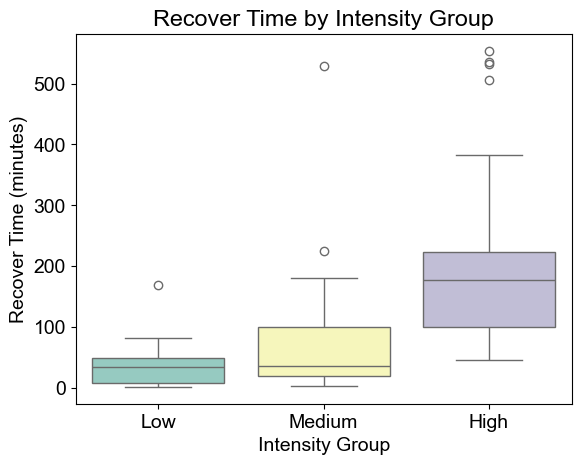

In [26]:
# 3. Group Comparison
# Group the data by standardized_intensity into three groups
results['intensity_group'] = pd.qcut(results['standardized_intensity'], q=3, labels=['Low', 'Medium', 'High'])

# Calculate the mean of recover_minute for each group
group_means = results.groupby('intensity_group')['recover_time'].mean()
print(group_means.round(2))

# One-way ANOVA
anova_result = stats.f_oneway(
    results[results['intensity_group'] == 'Low']['recover_time'],
    results[results['intensity_group'] == 'Medium']['recover_time'],
    results[results['intensity_group'] == 'High']['recover_time']
)
print(f"ANOVA F-statistic: {anova_result.statistic:.4f}, p-value: {anova_result.pvalue:.4e}")

# 可视化分组结果
sns.boxplot(x='intensity_group', y='recover_time', data=results, palette= "Set3")
plt.title("Recover Time by Intensity Group")
plt.xlabel("Intensity Group")
plt.ylabel("Recover Time (minutes)")
plt.show()

In [12]:
# 3. detect outliers
# use Z-score method to detect outliers
z_scores = stats.zscore(results[['standardized_intensity', 'recover_time']].dropna())
abs_z_scores = np.abs(z_scores)
outliers = (abs_z_scores > 3).any(axis=1)
outliers_count = outliers.sum()

print(f"\n outliers detected by Z-score method (|z| > 3): {outliers_count}")


 outliers detected by Z-score method (|z| > 3): 6


### By-Type Analysis (Crypto-related vs. Non-related)
#### Significance of differences between crypto-related and non-related events

In [13]:
# merge data
events_df = pd.read_csv('event_filter(incl_ob_hour_&_types).csv')
merged_df = pd.merge(events_df, results, left_on='event_index', right_on='Unnamed: 0', how='inner')

# check if the merge is successful
if 'Binary Type' not in merged_df.columns:
    raise ValueError("Binary Type column not found after merging!")
if 'Trinary Type' not in merged_df.columns:
    raise ValueError("Trinary Type column not found after merging!")
if 'MA5' not in merged_df.columns:
    raise ValueError("MA5 column not found after merging!")

# Convert Binary Type to numeric type for further analysis
# Assuming Binary Type 1 represents Crypto-related, 0 represents Non-related
merged_df['Binary_Type_Numeric'] = merged_df['Binary Type'].astype(int)

print("\n==== statistical tests - determine the significance of differences ====")

# extract data of different types
crypto_related = merged_df[merged_df['Binary Type'] == 1]
non_crypto_related = merged_df[merged_df['Binary Type'] == 0]

# statistical tests on standardized intensity
print("\nstatistical tests on standardized intensity:")
# check normality
print("Shapiro-Wilk normality test:")
print("crypto related events:", stats.shapiro(crypto_related['standardized_intensity'].dropna()))
print("non-crypto related events:", stats.shapiro(non_crypto_related['standardized_intensity'].dropna()))

# since the data may not satisfy the normal distribution assumption, use non-parametric Mann-Whitney U test
u_stat_intensity, p_value_intensity = stats.mannwhitneyu(
    crypto_related['standardized_intensity'].dropna(),
    non_crypto_related['standardized_intensity'].dropna(),
    alternative='two-sided'
)
print(f"Mann-Whitney U test (standardized intensity): U statistic = {u_stat_intensity}, p-value = {p_value_intensity}")
print(f"conclusion: {'significant difference' if p_value_intensity < 0.05 else 'no significant difference'} (α=0.05)")

# statistical tests on recover time
print("\nstatistical tests on recover time:")
# check normality
print("Shapiro-Wilk normality test:")
print("crypto related events:", stats.shapiro(crypto_related['recover_time'].dropna()))
print("non-crypto related events:", stats.shapiro(non_crypto_related['recover_time'].dropna()))

# since the data may not satisfy the normal distribution assumption, use non-parametric Mann-Whitney U test
u_stat_recover, p_value_recover = stats.mannwhitneyu(
    crypto_related['recover_time'].dropna(),
    non_crypto_related['recover_time'].dropna(),
    alternative='two-sided'
)
print(f"Mann-Whitney U test (recover time): U statistic = {u_stat_recover}, p-value = {p_value_recover}")
print(f"conclusion: {'significant difference' if p_value_recover < 0.05 else 'no significant difference'} (α=0.05)")



==== statistical tests - determine the significance of differences ====

statistical tests on standardized intensity:
Shapiro-Wilk normality test:
crypto related events: ShapiroResult(statistic=0.6227240482705889, pvalue=2.5867874099226307e-10)
non-crypto related events: ShapiroResult(statistic=0.7002197487744335, pvalue=1.0139519640047476e-05)
Mann-Whitney U test (standardized intensity): U statistic = 622.0, p-value = 0.9866263808456868
conclusion: no significant difference (α=0.05)

statistical tests on recover time:
Shapiro-Wilk normality test:
crypto related events: ShapiroResult(statistic=0.7296057004676639, pvalue=1.8803532006674352e-08)
non-crypto related events: ShapiroResult(statistic=0.7428837441700302, pvalue=3.927672352972915e-05)
Mann-Whitney U test (recover time): U statistic = 601.0, p-value = 0.8014655423864827
conclusion: no significant difference (α=0.05)


#### Descriptive Statistics

In [14]:
pd.set_option('display.width', 1000)        # set the width of the output
pd.set_option('display.max_columns', None)  # show all columns
pd.set_option('display.max_colwidth', None) # show all columns

# 4. Compare different types of events (Binary Type: Crypto-related vs. Non-related)
print("\n==== Compare different types of events (Binary Type: Crypto-related vs. Non-related) ====\n")

# Calculate descriptive statistics by Binary Type
binary_stats = merged_df.groupby('Binary Type')[['standardized_intensity', 'recover_time', 'peak_minute']].describe()

# Format and display Binary Type statistics
for metric in ['standardized_intensity', 'recover_time', 'peak_minute']:
    print(f"\n--- Descriptive Statistics for {metric} by Binary Type ---")
    # Round the statistics: count to 0 decimals, others to 2 decimals
    rounded_stats = binary_stats[metric].copy()
    rounded_stats = rounded_stats.round(2)  # Round other values to 2 decimals
    print(rounded_stats.to_string())  # Ensure single-line output


==== Compare different types of events (Binary Type: Crypto-related vs. Non-related) ====


--- Descriptive Statistics for standardized_intensity by Binary Type ---
             count  mean   std   min   25%   50%   75%    max
Binary Type                                                  
0             24.0  6.39  6.98  0.98  2.30  3.51  7.35  28.15
1             52.0  6.48  8.01  0.63  2.22  4.12  6.81  43.37

--- Descriptive Statistics for recover_time by Binary Type ---
             count   mean     std  min    25%   50%     75%    max
Binary Type                                                       
0             24.0  124.0  149.79  1.0  32.75  70.0  140.50  535.0
1             52.0  107.9  130.51  2.0  19.75  55.5  173.75  554.0

--- Descriptive Statistics for peak_minute by Binary Type ---
             count    mean     std  min    25%   50%   75%    max
Binary Type                                                      
0             24.0   93.17  107.07  0.0  37.75  53.0  82.0 

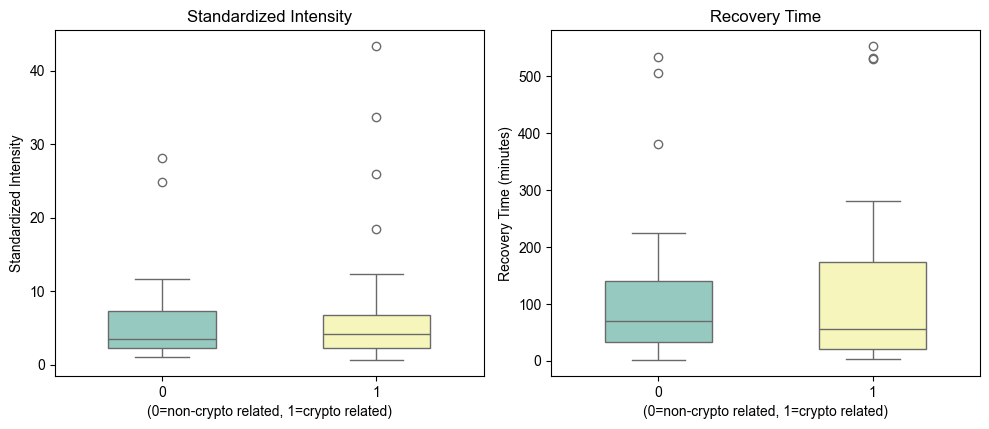

In [15]:
# visualize the differences between different types of events
plt.figure(figsize=(10, 8))

# Compare standardized intensity
plt.subplot(2, 2, 1)
sns.boxplot(x='Binary Type', y='standardized_intensity', width=0.5, data=merged_df, palette='Set3')
plt.title('Standardized Intensity')
plt.xlabel('(0=non-crypto related, 1=crypto related)')
plt.ylabel('Standardized Intensity')

# Compare recovery time
plt.subplot(2, 2, 2)
sns.boxplot(x='Binary Type', y='recover_time', width=0.5, data=merged_df, palette='Set3')
plt.title('Recovery Time')
plt.xlabel('(0=non-crypto related, 1=crypto related)')
plt.ylabel('Recovery Time (minutes)')

plt.tight_layout()
plt.show()

### Correlation Analysis

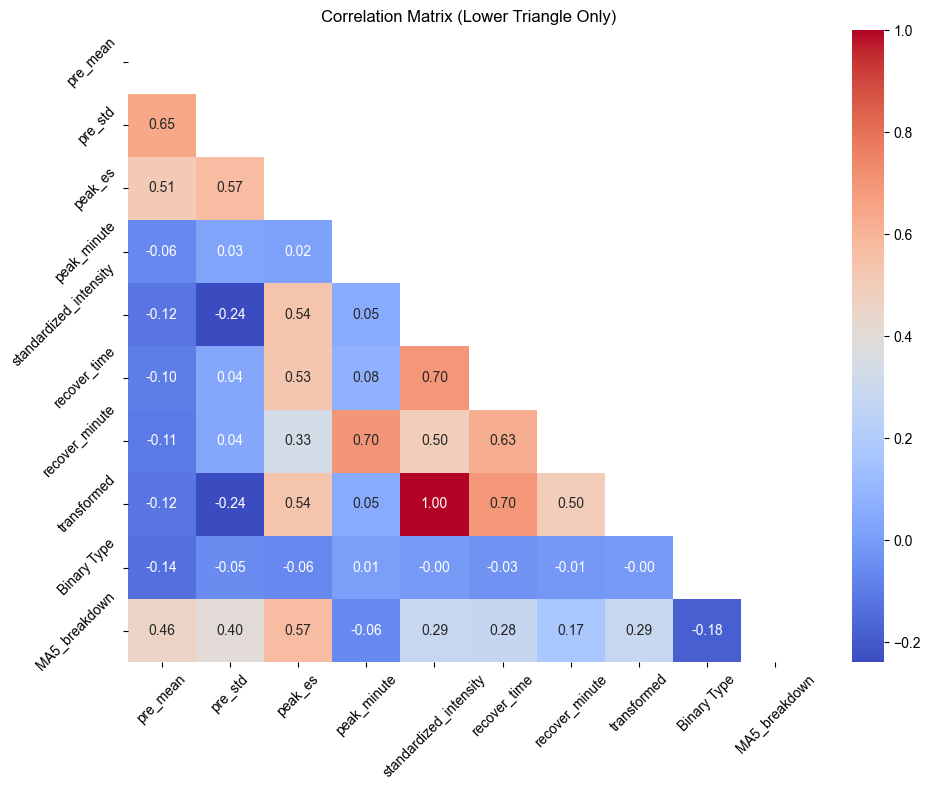

In [16]:
# Clean the MA5 column
# Remove the '%' sign and convert to float
events_df['MA5'] = events_df['MA5'].str.rstrip('%').astype('float') / 100.0

# Step 3: Merge the DataFrames
# Assuming 'event_index' is the key to join on
correlation_df = results.merge(
    events_df[['event_index', 'Binary Type', 'MA5']],
    left_on=results.columns[0],  # Assuming the first column is event_index
    right_on='event_index',
    how='left'
)
correlation_df = correlation_df.rename(columns={'MA5': 'MA5_breakdown'})
# change the MA5_breakdown to absolute value
correlation_df['MA5_breakdown'] = correlation_df['MA5_breakdown'].abs()

# Step 4: calculate the Correlation Matrix
correlation_matrix = correlation_df.corr(numeric_only=True, method='spearman')

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot the heatmap with the mask
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix (Lower Triangle Only)')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()

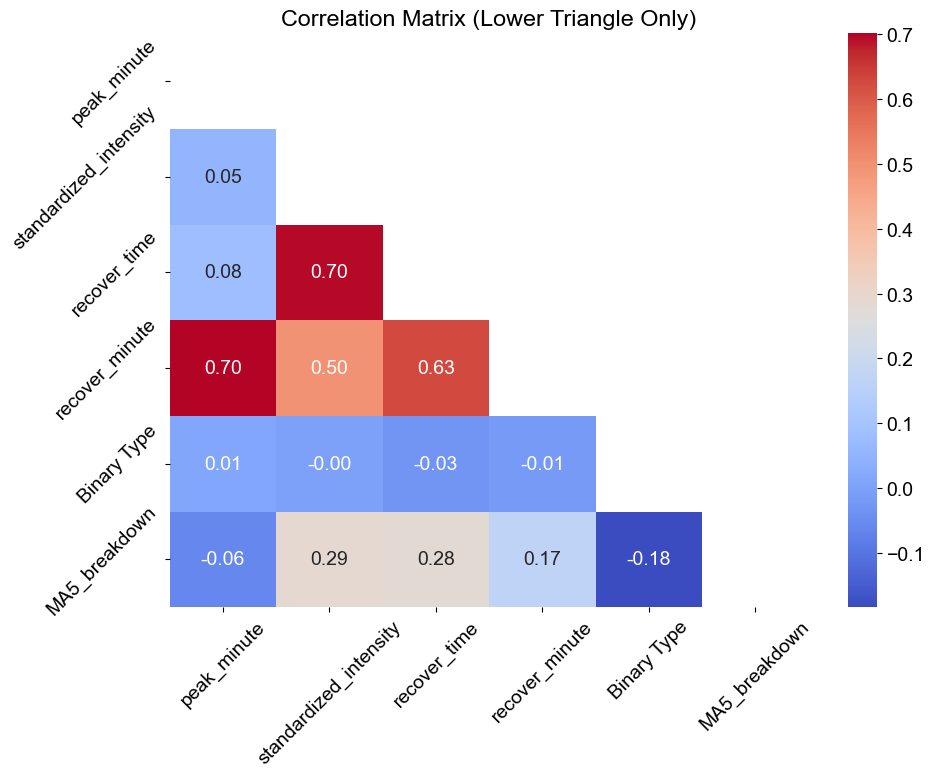

In [22]:
# Drop specified columns
'''
These columns are removed because they are the basis for calculating the target variables
and naturally have a positive or negative correlation with the target variables.
'''
columns_to_drop = ['pre_mean', 'pre_std', 'peak_es', 'valid_pes', 'transformed']
concise_df = correlation_df.drop(columns=columns_to_drop, errors='ignore')

# Step 6: Recalculate the Correlation Matrix
correlation_matrix = concise_df.corr(numeric_only=True, method='spearman')

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Plot the heatmap with the mask
plt.rcParams['font.size'] = 14
plt.figure(figsize=(10, 8), dpi = 100)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title('Correlation Matrix (Lower Triangle Only)')
plt.xticks(rotation=45)
plt.yticks(rotation=45)
plt.tight_layout()
plt.show()